# IGT Simulation

In [244]:
import numpy as np
import matplotlib.pyplot as plt

In [404]:
TIME_RESOLUTION = 0.001

In [405]:
def create_pulse_train(basic_voltage, pulse_voltage, pulse_duration, interval_duration, pulse_quantity):
    train_length = (pulse_duration + interval_duration) * pulse_quantity

    pulse_train = np.zeros(train_length) + basic_voltage

    for i in range(pulse_quantity):
        pulse_train[i * (pulse_duration + interval_duration): (i * (pulse_duration + interval_duration)) + (pulse_duration)] = pulse_voltage
    
    return pulse_train

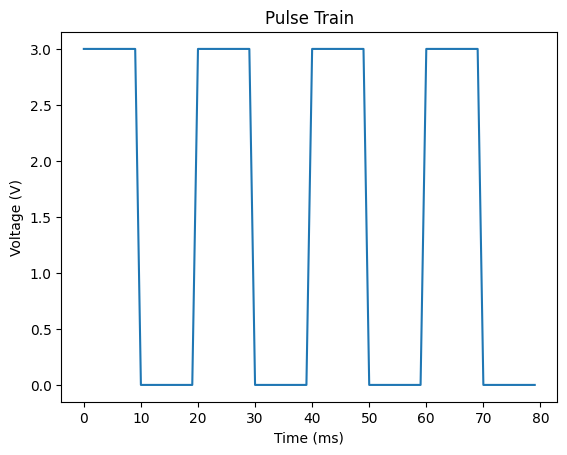

In [406]:
pulse_train = np.repeat(create_pulse_train(
    basic_voltage = 0,
    pulse_voltage = 3,
    pulse_duration = 10,
    interval_duration = 10, 
    pulse_quantity = 4
), TIME_RESOLUTION * 1000)

time = range(len(pulse_train))

plt.plot(time, pulse_train)
plt.title("Pulse Train")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.show()

In [512]:
def evolve_IGT(k, t, T, v, In_1, beta, tau, tau_dl):
    if v != 0:
        return k * (1 - np.exp(-(t/tau_dl))) #+ In_1
    
    return (k * (1 - np.exp(-(T/tau_dl))) + 0) * np.exp(-(t/tau)**beta)

def generate_out_current(pulse_train, k, beta, tau, tau_dl):
    out_current = np.zeros_like(pulse_train)

    t, T = 0, 0

    for i in range(1, len(out_current)):
        if pulse_train[i-1] == 0 and pulse_train[i] != 0:
            t = 0
        elif pulse_train[i-1] != 0 and pulse_train[i] == 0:
            T = t
            t = 0
        
        out_current[i] = evolve_IGT(k, t, T, pulse_train[i], out_current[i-1], beta, tau, tau_dl)

        t += TIME_RESOLUTION

    return out_current

In [513]:
BETA = 0.74
TAU = 0.009 #ms
TAU_DL = 0.257 #ms
K = 766 #nA

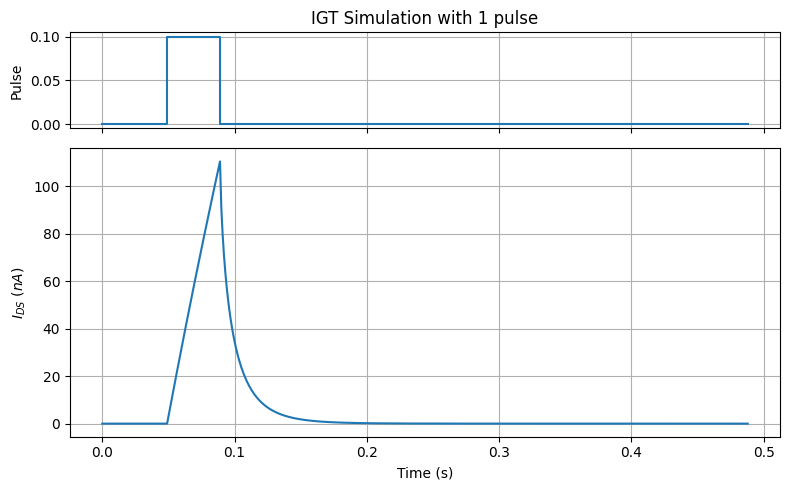

In [514]:
pulse_train = np.concatenate((
    np.zeros(49),
    create_pulse_train(0, 0.1, 40, 0, 1),
    np.zeros(400)
))

# pulse_train = np.repeat(pulse_train, 1000)

out_current = generate_out_current(pulse_train, K, BETA, TAU, TAU_DL)

time = np.arange(len(out_current)) * TIME_RESOLUTION

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Pulse train (parte superior)
ax1.step(time, pulse_train, where="post")
ax1.set_ylabel("Pulse")
ax1.set_title("IGT Simulation with 1 pulse")
ax1.grid(True)

# Corrente de saída (parte inferior)
ax2.plot(time, out_current)
# ax2.scatter(time, out_current)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"$I_{DS}\ (nA)$")
ax2.grid(True)

plt.tight_layout()
plt.show()

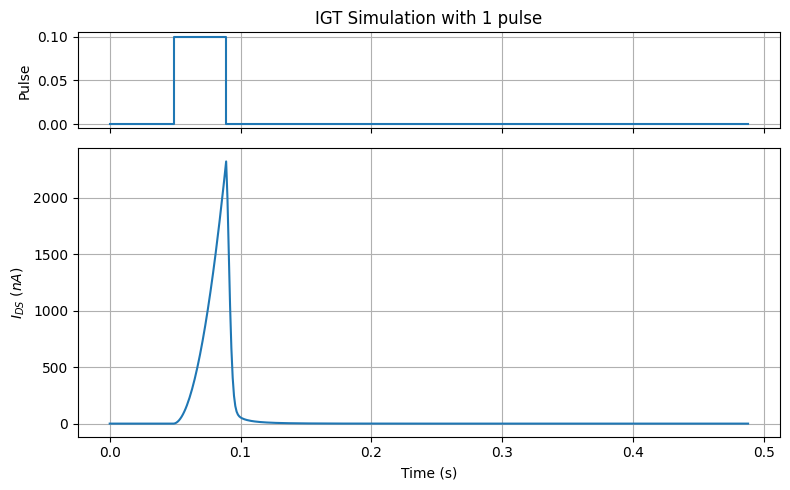

In [508]:
pulse_train = np.concatenate((
    np.zeros(49),
    create_pulse_train(0, 0.1, 40, 0, 1),
    np.zeros(400)
))

# pulse_train = np.repeat(pulse_train, 1000)

out_current = generate_out_current(pulse_train, K, BETA, TAU, TAU_DL)

time = np.arange(len(out_current)) * TIME_RESOLUTION

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# Pulse train (parte superior)
ax1.step(time, pulse_train, where="post")
ax1.set_ylabel("Pulse")
ax1.set_title("IGT Simulation with 1 pulse")
ax1.grid(True)

# Corrente de saída (parte inferior)
ax2.plot(time, out_current)
# ax2.scatter(time, out_current)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"$I_{DS}\ (nA)$")
ax2.grid(True)

plt.tight_layout()
plt.show()

---

Based on the following equation:

$$
\Delta I_{DS} = \left(I_n - I_{n-1}\right)
\exp\left[-\left(\frac{t-t_0}{\tau}\right)^{\beta}\right]
+ I_{n-1}
\tag{1}
$$

and the parameters $\beta = 0.57$ and $\tau = 2.6$, following those reported by Zhu _et al._ (2025) [1]...

In [304]:
BETA = 0.57
TAU = 2.6

VOLTAGE_TO_MAX_CURRENT = {
    3: 20,
    0: 0
}

In [301]:
def evolve_IGT(In, In_1, delta_t, beta, tau):
    return (In - In_1) * np.exp(-((delta_t / tau) ** beta)) + In_1

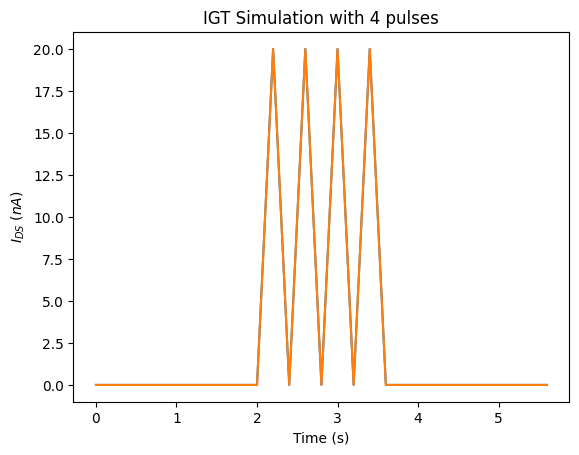

In [302]:
pulse_train = np.concatenate((np.zeros(11), create_pulse_train(0, 3, 1, 1, 4), np.zeros(10)))

# pulse_train = np.repeat(pulse_train, TIME_RESOLUTION)

out_current = np.zeros_like(pulse_train)

for i in range(1, len(out_current)):
    In = VOLTAGE_TO_MAX_CURRENT[pulse_train[i]]

    if pulse_train[i] == 0:
        out_current[i] = evolve_IGT(In, out_current[i-1], TIME_RESOLUTION, BETA * 200, TAU * 200)
    else:
        out_current[i] = In
    

# print(pulse_train)
# print(out_current)

plt.plot(np.array(range(len(out_current))) * 0.2, out_current)
plt.plot(np.array(range(len(out_current))) * 0.2, out_current)
plt.title("IGT Simulation with 4 pulses")
plt.xlabel("Time (s)")
plt.ylabel(r"$I_{DS}\ (nA)$")
plt.show()

In [295]:
from ipywidgets import interact, FloatSlider

In [298]:
def update_plot(beta, tau, time_resolution):
    pulse_train = np.concatenate((np.zeros(11), create_pulse_train(0, 3, 1, 1, 4), np.zeros(10)))

    # pulse_train = np.repeat(pulse_train, TIME_RESOLUTION)

    out_current = np.zeros_like(pulse_train)

    for i in range(1, len(out_current)):
        In = VOLTAGE_TO_MAX_CURRENT[pulse_train[i]]

        if pulse_train[i] == 0:
            out_current[i] = evolve_IGT(In, out_current[i-1], TIME_RESOLUTION, BETA * 200, TAU * 200)
        else:
            out_current[i] = In
        

    # print(pulse_train)
    # print(out_current)

    plt.plot(np.array(range(len(out_current))) * 0.2, out_current)
    plt.title("IGT Simulation with 4 pulses")
    plt.xlabel(r"$I_{DS}\ (A)$")
    plt.ylabel("Time (s)")
    plt.show()

interact(
    update_plot,
    beta = FloatSlider(value=0.57, min = 0.01, max = 3, step = 0.01),
    tau = FloatSlider(value=2.6, min = 0.01, max = 3, step = 0.01),
    time_resolution = FloatSlider(value = 200, min=0.2, max=2000, step=0.1)
)

interactive(children=(FloatSlider(value=0.57, description='beta', max=3.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.update_plot(beta, tau, time_resolution)>

## References

[1] Zhu, L., Wan, X., Lin, J., Chen, P., Luo, Z., Sun, H., Yan, S., Tan, C. L., Yu, Z., & Xu, Y. (2025). *Reservoir computing for image processing based on ion-gated flexible organic transistors with nonlinear synaptic dynamics*. **Organic Electronics, 139**, 107199. https://doi.org/10.1016/j.orgel.2025.107199